<a href="https://colab.research.google.com/github/crahulnaidu/recursive-self-improving-ai/blob/main/month_1/ai_month_1_day_14_projectA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs,make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


def train_and_visualize(mode,lr=0.1,reg_strength=1.0,scale=True):
  if mode=='binary':
    X,y=make_classification(n_samples=200,n_features=2,n_redundant=0,n_clusters_per_class=1,random_state=42)
    multi_class='ovr' #Binary logic
  else:
    X,y=make_blobs(n_samples=300,centers=3,n_features=2,random_state=42)
    multi_class='multnomial' #Softmax logic

  #Scaling

  if scale:
    scaling=StandardScaler()
    scaling.fit_transform(X)

  #Training with learning rate and regularization.

  clf=SGDClassifier(loss='log_loss',learning_rate='constant',eta0=lr,alpha=1/reg_strength,max_iter=100,random_state=42)
  clf.fit(X,y)

  #Visualization of Decision boundary

  x_min,x_max=X[:,0].min()-1,X[:,0].max()+1
  y_min,y_max=X[:,1].min()-1,X[:,1].max()+1

  xx,yy=np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.02))
  Z=clf.predict(np.c_[xx.ravel(),yy.ravel()])

  Z=Z.reshape(xx.shape)

  plt.figure(figsize=(8,6))
  plt.contourf(xx,yy,Z,alpha=0.3)
  plt.scatter(X[:,0],X[:,1],c=y,edgecolors='k',cmap=plt.cm.Paired)
  plt.title(f"Mode:{mode.upper()}| LR:{lr}| Reg:{reg_strength}| Scaling:{scale}")
  plt.xlabel("Feature1")
  plt.ylabel("Feature2")



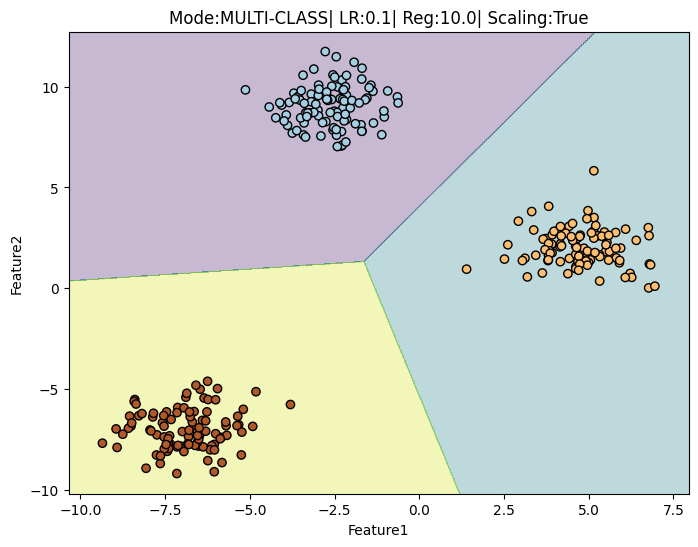

In [17]:
train_and_visualize('multi-class',0.1,10.0,True)